In [3]:
# # Neural Network for Dynamic Adaptive Network-Aware Compression

# **Goal:** Train a neural network that predicts the effective error (QoE metric) for each user given the current network state, video characteristics, and compression level. At inference time, sweep all 16 compression levels per user to select the one minimizing effective error.

# **Approach:**
# 1. **Input:** Per-user features — video characteristics (`meantrafficsize`, `stdtrafficsize`, `frameComplexity`), channel quality (`CQI`, embedded), and compression level (`components`). All users' features are concatenated to capture cross-user network dependencies.
# 2. **Output:** Predicted effective error per user.
# 3. **Inference:** Coordinate descent over compression levels — for each user, evaluate all 16 options, pick the one minimizing total predicted error across all users.
# 4. **Separate models** for each user count configuration (2–10 users).

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os, json, copy, pickle

# ── Configuration ──────────────────────────────────────────────
DATASET_PATH = "datasets/random_cl_dataset_clean.csv"
MODEL_DIR    = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

COMP_LEVELS     = list(range(25, 401, 25))   # 16 levels: 25, 50, …, 400
NUM_COMP_LEVELS = len(COMP_LEVELS)
CQI_MIN         = 6                          # min CQI in dataset
CQI_MAX         = 15                         # max CQI in dataset
CQI_VOCAB_SIZE  = CQI_MAX - CQI_MIN + 1     # 10 bins (indices 0-9)
CQI_EMBED_DIM   = 4
HIDDEN_DIMS     = [256, 128, 64]
BATCH_SIZE      = 256
LEARNING_RATE   = 1e-3
EPOCHS          = 150
PATIENCE        = 15                         # early stopping patience

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Compression levels ({NUM_COMP_LEVELS}): {COMP_LEVELS}")
print(f"CQI bins: {CQI_MIN}–{CQI_MAX} → {CQI_VOCAB_SIZE} embeddings")

Device: cuda
Compression levels (16): [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400]
CQI bins: 6–15 → 10 embeddings


## 1. Data Loading & Exploration

Dataset shape: (33504, 72)

Samples per user-count configuration:
num_users
2     4530
3     4204
4     3666
5     3313
6     3610
7     3589
8     3592
9     3561
10    3439

CQI values:  [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Comp levels: [np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(125), np.int64(150), np.int64(175), np.int64(200), np.int64(225), np.int64(250), np.int64(275), np.int64(300), np.int64(325), np.int64(350), np.int64(375), np.int64(400)]


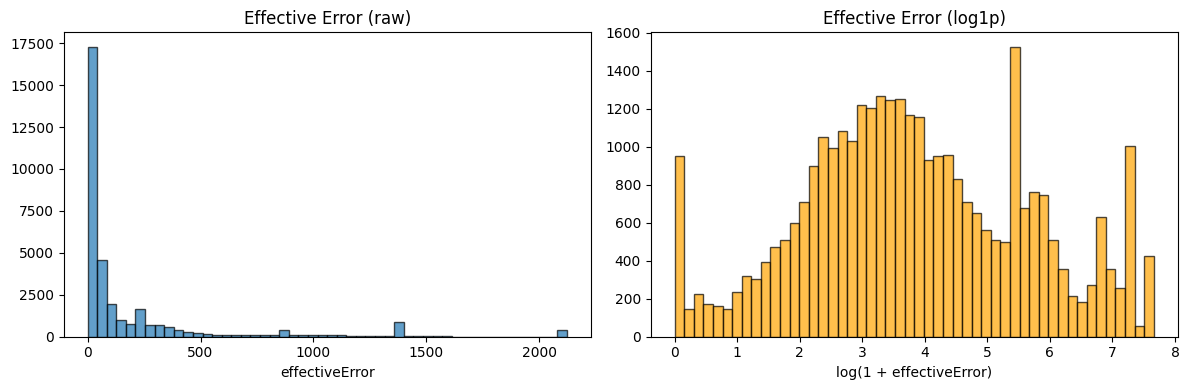

In [14]:
df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nSamples per user-count configuration:")
print(df['num_users'].value_counts().sort_index().to_string())

# Quick sanity check
all_cqi = set()
all_comp = set()
for i in range(10):
    all_cqi.update(df[f'user{i}_cqi'].dropna().astype(int).unique())
    all_comp.update(df[f'user{i}_components'].dropna().astype(int).unique())
print(f"\nCQI values:  {sorted(all_cqi)}")
print(f"Comp levels: {sorted(all_comp)}")

# Effective error distribution (user0 as representative)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['user0_effectiveError'], bins=50, edgecolor='k', alpha=0.7)
axes[0].set_title('Effective Error (raw)')
axes[0].set_xlabel('effectiveError')
axes[1].hist(np.log1p(df['user0_effectiveError']), bins=50, edgecolor='k', alpha=0.7, color='orange')
axes[1].set_title('Effective Error (log1p)')
axes[1].set_xlabel('log(1 + effectiveError)')
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

For each `num_users` configuration we extract per-user features:
- **Continuous (4):** `meantrafficsize`, `stdtrafficsize`, `frameComplexity`, `components`
- **Discrete (1):** `CQI` → mapped to embedding index `[0, 9]`
- **Target:** `effectiveError` (log1p-transformed for training)

A single `StandardScaler` is fit on the pooled continuous features across all user slots so that the same physical quantity always gets the same normalization.

In [6]:
CONT_FEAT_NAMES = ['meantrafficsize', 'stdtrafficsize', 'frameComplexity', 'components']
NUM_CONT_FEATS  = len(CONT_FEAT_NAMES)

def extract_features(df, num_users):
    """Return (X_cont, X_cqi, y) arrays for a given num_users slice."""
    subset = df[df['num_users'] == num_users].reset_index(drop=True)
    n = len(subset)

    X_cont = np.zeros((n, num_users, NUM_CONT_FEATS), dtype=np.float32)
    X_cqi  = np.zeros((n, num_users), dtype=np.int64)
    y      = np.zeros((n, num_users), dtype=np.float32)

    for u in range(num_users):
        for j, feat in enumerate(CONT_FEAT_NAMES):
            X_cont[:, u, j] = subset[f'user{u}_{feat}'].values
        X_cqi[:, u] = subset[f'user{u}_cqi'].values.astype(int) - CQI_MIN
        y[:, u]     = subset[f'user{u}_effectiveError'].values

    return X_cont, X_cqi, y


# ── Fit a global scaler on ALL continuous features (pooled across configs & users) ─
all_cont = []
for n_u in range(2, 11):
    xc, _, _ = extract_features(df, n_u)
    all_cont.append(xc.reshape(-1, NUM_CONT_FEATS))

global_scaler = StandardScaler().fit(np.concatenate(all_cont, axis=0))
print("Global scaler fitted on", np.concatenate(all_cont).shape[0], "user-samples")
print(f"  means: {global_scaler.mean_}")
print(f"  stds:  {global_scaler.scale_}")


# ── Build per-config datasets ─────────────────────────────────
class XRDataset(Dataset):
    """PyTorch dataset for a single num_users configuration."""
    def __init__(self, X_cont, X_cqi, y, scaler):
        # Normalize continuous features
        shape = X_cont.shape
        X_flat = scaler.transform(X_cont.reshape(-1, NUM_CONT_FEATS))
        self.X_cont = torch.tensor(X_flat.reshape(shape), dtype=torch.float32)
        self.X_cqi  = torch.tensor(X_cqi, dtype=torch.long)
        # Log-transform targets
        self.y = torch.tensor(np.log1p(y), dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cont[idx], self.X_cqi[idx], self.y[idx]


datasets = {}   # num_users -> (train_ds, val_ds, test_ds)
for n_u in range(2, 11):
    xc, xcqi, yy = extract_features(df, n_u)
    ds = XRDataset(xc, xcqi, yy, global_scaler)

    n_total = len(ds)
    n_test  = int(0.10 * n_total)
    n_val   = int(0.10 * n_total)
    n_train = n_total - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        ds, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )
    datasets[n_u] = (train_ds, val_ds, test_ds)
    print(f"num_users={n_u:>2d}  →  train={n_train}, val={n_val}, test={n_test}")

Global scaler fitted on 194859 user-samples
  means: [19339.89776903 54767.85275807 19055.05652805   212.01753576]
  stds:  [17485.93573753 75414.32025216 93589.48973191   115.64655732]
num_users= 2  →  train=3624, val=453, test=453
num_users= 3  →  train=3364, val=420, test=420
num_users= 4  →  train=2934, val=366, test=366
num_users= 5  →  train=2651, val=331, test=331
num_users= 6  →  train=2888, val=361, test=361
num_users= 7  →  train=2873, val=358, test=358
num_users= 8  →  train=2874, val=359, test=359
num_users= 9  →  train=2849, val=356, test=356
num_users=10  →  train=2753, val=343, test=343


## 3. Model Architecture

A fully-connected network with:
- **CQI Embedding** layer (10 bins → 4-dim vector) to represent discrete channel quality
- **Hidden layers** `[256 → 128 → 64]` with BatchNorm, ReLU, and Dropout
- **Output:** one predicted log-effective-error per user

The full input is the concatenation of all users' features (continuous + CQI embedding), so the model inherently captures **cross-user network dependencies** (e.g., how one user's traffic load affects others' quality).

In [7]:
class CompressionPredictor(nn.Module):
    """
    Predicts effective error for every user given all users' features.

    Inputs
    ------
    x_cont : (B, N, 4)   – normalised [meantrafficsize, stdtrafficsize,
                            frameComplexity, components]
    x_cqi  : (B, N)      – CQI index (0-9)

    Output
    ------
    (B, N)  – predicted log(1 + effectiveError) per user
    """

    def __init__(self, num_users, cqi_vocab=CQI_VOCAB_SIZE,
                 cqi_dim=CQI_EMBED_DIM, hidden=None):
        super().__init__()
        if hidden is None:
            hidden = HIDDEN_DIMS
        self.num_users = num_users
        self.cqi_embed = nn.Embedding(cqi_vocab, cqi_dim)

        per_user = NUM_CONT_FEATS + cqi_dim          # 4 + 4 = 8
        in_dim   = num_users * per_user

        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers.append(nn.Linear(prev, num_users))
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_cqi):
        cqi_emb = self.cqi_embed(x_cqi)                         # (B, N, cqi_dim)
        x = torch.cat([x_cont, cqi_emb], dim=-1)                # (B, N, 8)
        x = x.view(x.size(0), -1)                               # (B, N*8)
        return self.net(x)                                       # (B, N)


# Quick check
_m = CompressionPredictor(num_users=5).to(DEVICE)
_x = torch.randn(2, 5, NUM_CONT_FEATS).to(DEVICE)
_c = torch.randint(0, CQI_VOCAB_SIZE, (2, 5)).to(DEVICE)
print(f"Sample output shape: {_m(_x, _c).shape}")            # (2, 5)
n_params = sum(p.numel() for p in _m.parameters())
print(f"Parameters (5-user model): {n_params:,}")

Sample output shape: torch.Size([2, 5])
Parameters (5-user model): 52,909


## 4. Training

- **Loss:** MSE on log(1 + effectiveError) — the log transform compresses the wide error range (0.001 – 2100) and ensures the model learns relative differences well.
- **Optimizer:** Adam with ReduceLROnPlateau scheduler.
- **Early stopping** on validation loss (patience = 15 epochs).

In [8]:
def train_model(num_users, train_ds, val_ds, epochs=EPOCHS, patience=PATIENCE):
    """Train a CompressionPredictor for a given user count. Returns (model, history)."""
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

    model = CompressionPredictor(num_users).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=7, factor=0.5)
    loss_fn = nn.MSELoss()

    best_val, best_state, wait = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for ep in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t_loss = 0.0
        for xc, xcqi, yt in train_dl:
            xc, xcqi, yt = xc.to(DEVICE), xcqi.to(DEVICE), yt.to(DEVICE)
            pred = model(xc, xcqi)
            loss = loss_fn(pred, yt)
            opt.zero_grad(); loss.backward(); opt.step()
            t_loss += loss.item() * xc.size(0)
        t_loss /= len(train_ds)

        # ── Validate ──
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xc, xcqi, yt in val_dl:
                xc, xcqi, yt = xc.to(DEVICE), xcqi.to(DEVICE), yt.to(DEVICE)
                v_loss += loss_fn(model(xc, xcqi), yt).item() * xc.size(0)
        v_loss /= len(val_ds)
        sched.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)

        # ── Early stopping ──
        if v_loss < best_val:
            best_val = v_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {ep}")
                break

        if ep % 25 == 0 or ep == 1:
            print(f"  Epoch {ep:>3d}  train={t_loss:.5f}  val={v_loss:.5f}  lr={opt.param_groups[0]['lr']:.1e}")

    model.load_state_dict(best_state)
    return model, history

In [9]:
# ── Train all 9 models (num_users = 2 … 10) ──────────────────
models    = {}   # num_users -> trained model
histories = {}   # num_users -> history dict

for n_u in range(2, 11):
    print(f"\n{'='*50}")
    print(f"Training model for num_users = {n_u}")
    print(f"{'='*50}")
    train_ds, val_ds, test_ds = datasets[n_u]
    model, hist = train_model(n_u, train_ds, val_ds)
    models[n_u]    = model
    histories[n_u] = hist
    print(f"  Best val loss: {min(hist['val_loss']):.5f}")

print("\n✓ All 9 models trained.")


Training model for num_users = 2
  Epoch   1  train=12.76577  val=13.36280  lr=1.0e-03
  Epoch  25  train=1.71212  val=1.59231  lr=1.0e-03
  Epoch  50  train=1.62781  val=1.59635  lr=5.0e-04
  Early stop at epoch 62
  Best val loss: 1.57164

Training model for num_users = 3
  Epoch   1  train=20.30277  val=20.28190  lr=1.0e-03
  Epoch  25  train=1.65647  val=1.61938  lr=1.0e-03
  Epoch  50  train=1.53039  val=1.58001  lr=1.0e-03
  Early stop at epoch 59
  Best val loss: 1.54728

Training model for num_users = 4
  Epoch   1  train=16.45484  val=17.05162  lr=1.0e-03
  Epoch  25  train=1.81246  val=1.91132  lr=1.0e-03
  Epoch  50  train=1.60232  val=1.86623  lr=5.0e-04
  Early stop at epoch 72
  Best val loss: 1.84885

Training model for num_users = 5
  Epoch   1  train=20.58687  val=20.99170  lr=1.0e-03
  Epoch  25  train=1.83362  val=1.82389  lr=1.0e-03
  Epoch  50  train=1.56495  val=1.73978  lr=5.0e-04
  Early stop at epoch 68
  Best val loss: 1.72219

Training model for num_users = 

## 5. Evaluation

Evaluate each model on its held-out test set:
- **MSE** on log-transformed targets (training metric)
- **MAE** on original-scale effective error (interpretable metric)
- Training / validation loss curves

num_users= 2  test MSE(log)=1.71407  test MAE(orig)=131.17
num_users= 3  test MSE(log)=1.53700  test MAE(orig)=222.38
num_users= 4  test MSE(log)=1.65070  test MAE(orig)=155.38
num_users= 5  test MSE(log)=1.93664  test MAE(orig)=228.40
num_users= 6  test MSE(log)=2.01338  test MAE(orig)=210.42
num_users= 7  test MSE(log)=1.95654  test MAE(orig)=208.37
num_users= 8  test MSE(log)=2.10133  test MAE(orig)=256.99
num_users= 9  test MSE(log)=1.86000  test MAE(orig)=210.08
num_users=10  test MSE(log)=1.91654  test MAE(orig)=214.96


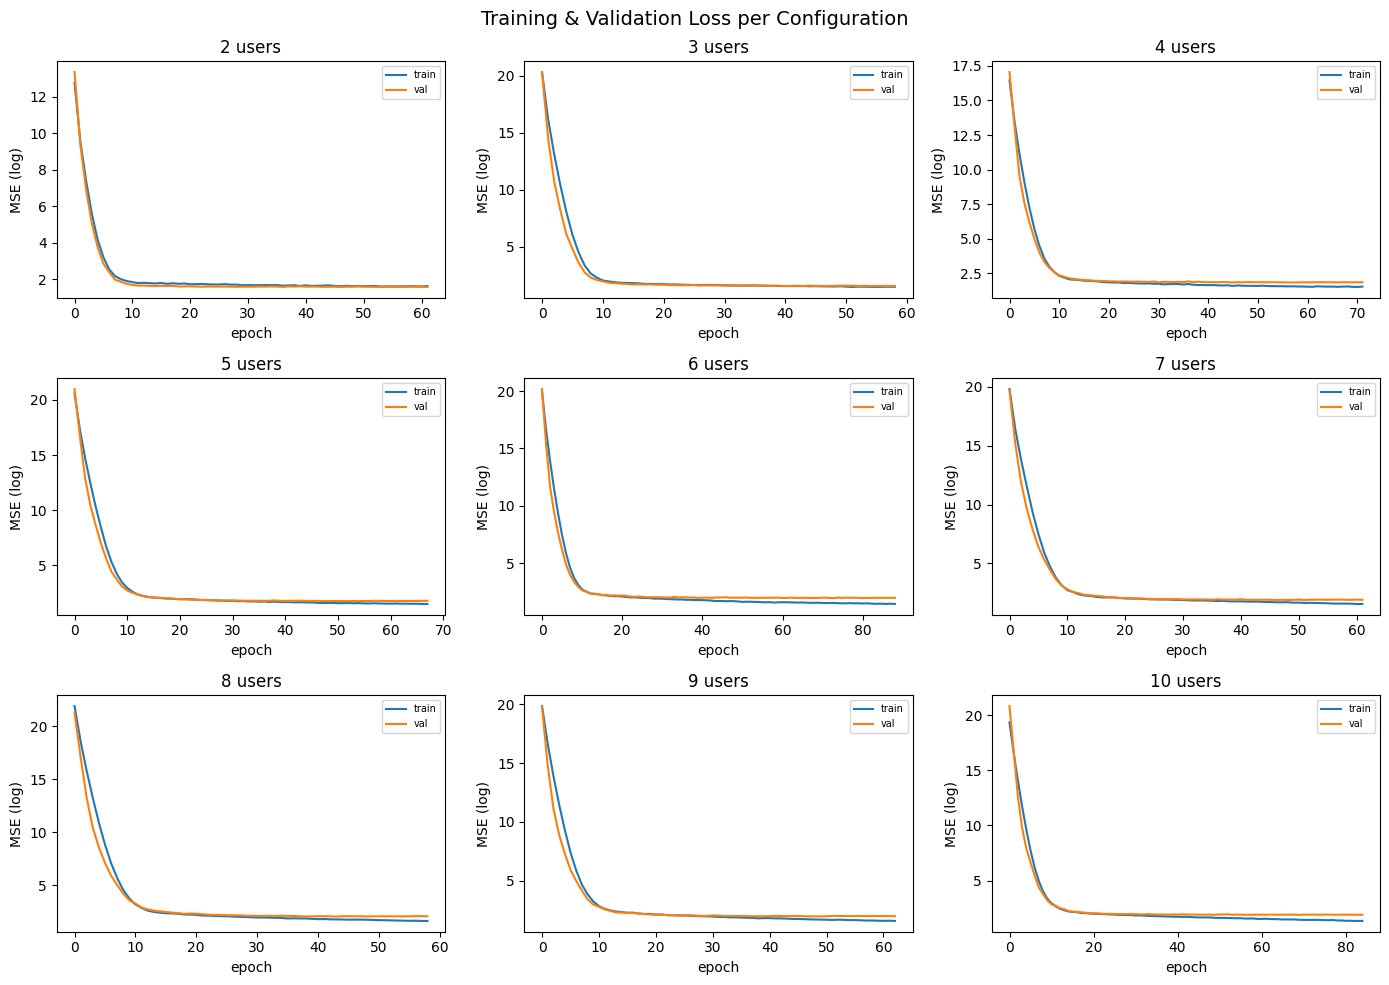

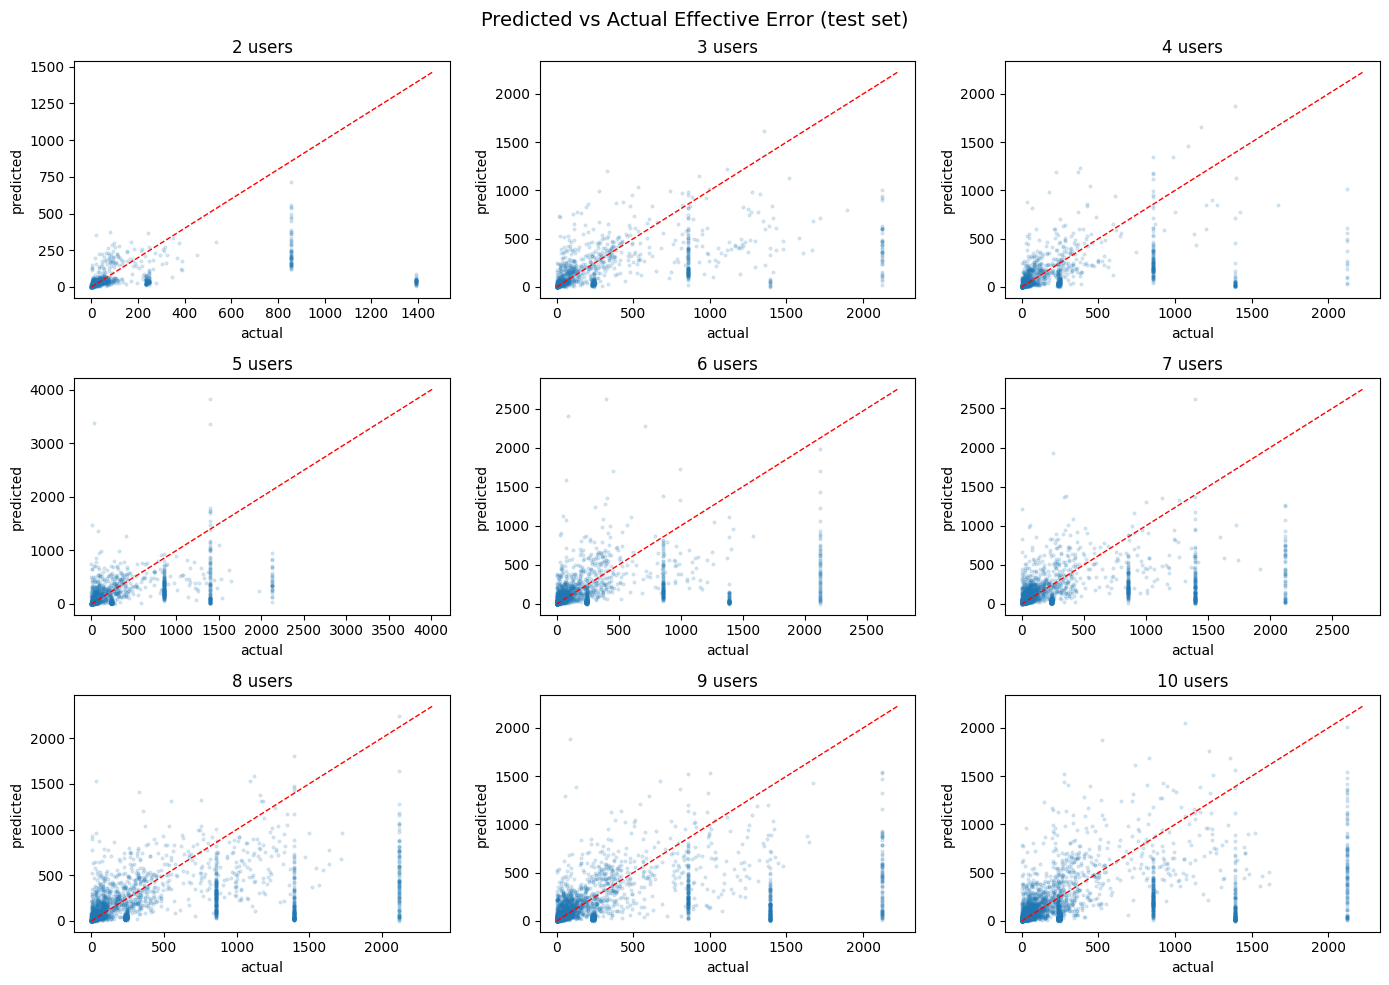

In [10]:
def evaluate_model(model, test_ds):
    """Return dict with test_mse_log, test_mae_original."""
    dl = DataLoader(test_ds, batch_size=512)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xc, xcqi, yt in dl:
            xc, xcqi, yt = xc.to(DEVICE), xcqi.to(DEVICE), yt.to(DEVICE)
            preds.append(model(xc, xcqi).cpu())
            trues.append(yt.cpu())
    preds = torch.cat(preds); trues = torch.cat(trues)
    mse_log = nn.MSELoss()(preds, trues).item()

    # Back to original scale
    preds_orig = torch.expm1(preds)
    trues_orig = torch.expm1(trues)
    mae_orig = (preds_orig - trues_orig).abs().mean().item()

    return {'mse_log': mse_log, 'mae_orig': mae_orig,
            'preds_orig': preds_orig.numpy(), 'trues_orig': trues_orig.numpy()}


# ── Evaluate all models ──
results = {}
for n_u in range(2, 11):
    _, _, test_ds = datasets[n_u]
    res = evaluate_model(models[n_u], test_ds)
    results[n_u] = res
    print(f"num_users={n_u:>2d}  test MSE(log)={res['mse_log']:.5f}  "
          f"test MAE(orig)={res['mae_orig']:.2f}")

# ── Loss curves ──
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=False)
for idx, n_u in enumerate(range(2, 11)):
    ax = axes[idx // 3][idx % 3]
    h = histories[n_u]
    ax.plot(h['train_loss'], label='train')
    ax.plot(h['val_loss'],   label='val')
    ax.set_title(f'{n_u} users')
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE (log)')
    ax.legend(fontsize=7)
plt.suptitle('Training & Validation Loss per Configuration', fontsize=14)
plt.tight_layout()
plt.show()

# ── Predicted vs Actual scatter (aggregate) ──
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for idx, n_u in enumerate(range(2, 11)):
    ax = axes[idx // 3][idx % 3]
    r = results[n_u]
    ax.scatter(r['trues_orig'].flatten(), r['preds_orig'].flatten(),
               alpha=0.15, s=4)
    lim = max(r['trues_orig'].max(), r['preds_orig'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_title(f'{n_u} users')
    ax.set_xlabel('actual'); ax.set_ylabel('predicted')
plt.suptitle('Predicted vs Actual Effective Error (test set)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Inference — Finding Optimal Compression Levels

At each TTI the system knows each user's **video characteristics** (`meantrafficsize`, `stdtrafficsize`, `frameComplexity`) and current **CQI**. It needs to choose the best **compression level** (`components`) for every user.

**Algorithm — Coordinate Descent:**
1. Initialize every user's compression to the median level (200).
2. For each user in turn, sweep all 16 compression levels while holding all other users fixed.
3. Pick the level that **minimizes the sum of predicted effective errors** across all users (joint optimization captures cross-user network effects).
4. Repeat rounds until stable (typically 2–3 rounds converge).

In [11]:
@torch.no_grad()
def predict_errors(model, x_cont_np, x_cqi_np, scaler):
    """
    Predict effective errors for a batch of inputs.

    x_cont_np : (B, N, 4) raw continuous features (incl. components)
    x_cqi_np  : (B, N)    CQI indices (0-based)
    Returns    : (B, N)    predicted effective error (original scale)
    """
    model.eval()
    shape = x_cont_np.shape
    x_scaled = scaler.transform(x_cont_np.reshape(-1, NUM_CONT_FEATS)).reshape(shape)
    xc  = torch.tensor(x_scaled, dtype=torch.float32).to(DEVICE)
    xcq = torch.tensor(x_cqi_np, dtype=torch.long).to(DEVICE)
    pred_log = model(xc, xcq)
    return torch.expm1(pred_log).cpu().numpy()


def find_optimal_compression(model, user_features, user_cqi, scaler,
                              comp_levels=COMP_LEVELS, max_rounds=5):
    """
    Coordinate-descent search for the joint compression configuration
    that minimizes total predicted effective error.

    Parameters
    ----------
    model          : trained CompressionPredictor
    user_features  : (N, 3) array — [meantrafficsize, stdtrafficsize,
                     frameComplexity] per user  (NO components column)
    user_cqi       : (N,) int array — CQI indices (0-based)
    scaler         : fitted StandardScaler (expects 4-feature input)

    Returns
    -------
    best_comp      : list[int] — chosen compression level per user
    best_errors    : (N,) array — predicted error at the chosen levels
    """
    N = model.num_users
    current_comp = [200] * N           # start at midpoint

    for rnd in range(max_rounds):
        changed = False
        for u in range(N):
            best_c, best_total = current_comp[u], float('inf')

            # Build batch: one row per candidate compression for user u
            x_cont = np.tile(user_features, (len(comp_levels), 1, 1))  # (16, N, 3)
            comp_col = np.array([current_comp] * len(comp_levels), dtype=np.float32)  # (16, N)
            for ci, cl in enumerate(comp_levels):
                comp_col[ci, u] = cl
            x_full = np.concatenate([x_cont, comp_col[..., None]], axis=-1)  # (16, N, 4)
            x_cqi  = np.tile(user_cqi, (len(comp_levels), 1))                # (16, N)

            errors = predict_errors(model, x_full, x_cqi, scaler)            # (16, N)
            total_errors = errors.sum(axis=1)                                 # (16,)

            best_idx = int(np.argmin(total_errors))
            if comp_levels[best_idx] != current_comp[u]:
                current_comp[u] = comp_levels[best_idx]
                changed = True

        if not changed:
            break

    # Final prediction at the chosen compression levels
    x_cont_final = user_features[None, :, :]                            # (1, N, 3)
    comp_final   = np.array(current_comp, dtype=np.float32).reshape(1, N, 1)
    x_full_final = np.concatenate([x_cont_final, comp_final], axis=-1)  # (1, N, 4)
    x_cqi_final  = user_cqi[None, :]                                    # (1, N)
    final_errors = predict_errors(model, x_full_final, x_cqi_final, scaler)[0]

    return current_comp, final_errors

In [12]:
# ── Demo: pick a random test sample and find optimal compression ──────────

demo_n_u = 3   # change to any config 2–10
_, _, test_ds = datasets[demo_n_u]

# Grab one sample from test set (in original scale)
sample_idx = 0
xc_s, xcqi_s, yt_s = test_ds[sample_idx]

# Un-normalise continuous features to get raw values
xc_raw = global_scaler.inverse_transform(
    xc_s.numpy().reshape(-1, NUM_CONT_FEATS)
).reshape(demo_n_u, NUM_CONT_FEATS)

user_feats_no_comp = xc_raw[:, :3]                   # (N, 3) without components
user_cqi_idx       = xcqi_s.numpy()                    # (N,)
actual_comp        = xc_raw[:, 3].astype(int).tolist() # original components
actual_error       = np.expm1(yt_s.numpy())            # original-scale error

opt_comp, opt_errors = find_optimal_compression(
    models[demo_n_u], user_feats_no_comp, user_cqi_idx, global_scaler
)

print(f"{'User':>6s}  {'CQI':>4s}  {'Actual comp':>11s}  {'Actual err':>10s}  "
      f"{'Optimal comp':>12s}  {'Pred err':>10s}")
print("-" * 70)
for u in range(demo_n_u):
    print(f"{u:>6d}  {user_cqi_idx[u]+CQI_MIN:>4d}  {actual_comp[u]:>11d}  "
          f"{actual_error[u]:>10.3f}  {opt_comp[u]:>12d}  {opt_errors[u]:>10.3f}")

  User   CQI  Actual comp  Actual err  Optimal comp    Pred err
----------------------------------------------------------------------
     0    14          100    1392.803           325      28.019
     1    14          325     191.405           350      88.356
     2    14           50     489.613           375     171.111


## 7. Save Models & Artifacts

Save each model's state dict, the global scaler, and config so models can be loaded for inference in the simulation loop.

In [13]:
# ── Save all models, scaler, and config ──────────────────────
config = {
    'comp_levels': COMP_LEVELS,
    'cqi_min': CQI_MIN, 'cqi_max': CQI_MAX,
    'cqi_vocab_size': CQI_VOCAB_SIZE,
    'cqi_embed_dim': CQI_EMBED_DIM,
    'hidden_dims': HIDDEN_DIMS,
    'cont_feat_names': CONT_FEAT_NAMES,
    'log_transform_target': True,
}

# Save config
with open(os.path.join(MODEL_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

# Save scaler
with open(os.path.join(MODEL_DIR, 'global_scaler.pkl'), 'wb') as f:
    pickle.dump(global_scaler, f)

# Save each model + TorchScript export
for n_u in range(2, 11):
    model = models[n_u]
    model.eval()

    # State dict
    torch.save(model.state_dict(),
               os.path.join(MODEL_DIR, f'model_{n_u}users.pt'))

    # TorchScript (for C++ integration / fast inference)
    dummy_xc  = torch.randn(1, n_u, NUM_CONT_FEATS).to(DEVICE)
    dummy_cqi = torch.zeros(1, n_u, dtype=torch.long).to(DEVICE)
    scripted  = torch.jit.trace(model, (dummy_xc, dummy_cqi))
    scripted.save(os.path.join(MODEL_DIR, f'model_{n_u}users_scripted.pt'))

print(f"✓ Saved to {MODEL_DIR}/")
print(f"  config.json, global_scaler.pkl")
for n_u in range(2, 11):
    print(f"  model_{n_u}users.pt  |  model_{n_u}users_scripted.pt")

✓ Saved to models/
  config.json, global_scaler.pkl
  model_2users.pt  |  model_2users_scripted.pt
  model_3users.pt  |  model_3users_scripted.pt
  model_4users.pt  |  model_4users_scripted.pt
  model_5users.pt  |  model_5users_scripted.pt
  model_6users.pt  |  model_6users_scripted.pt
  model_7users.pt  |  model_7users_scripted.pt
  model_8users.pt  |  model_8users_scripted.pt
  model_9users.pt  |  model_9users_scripted.pt
  model_10users.pt  |  model_10users_scripted.pt
